In [1]:
#Importando bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime as dt
import plotly.express as px
import numpy as np

#Caso a plotly não abra por aki, abrir pelo navegador::
#import plotly.io as pio
#pio.renderers.default = 'browser'

In [2]:
#Carregando os dados do SunEarthTools.com (df1) e Blender (df2)
df1 = pd.read_excel(r"C:\Users\abcal\OneDrive\Documentos\CECA\PIBIC 2526\DADOS SIMULACAO\SUNEARTHTOOLS.COM\SET_21_12_24.xlsx")
df2 = pd.read_csv(r"C:\Users\abcal\OneDrive\Documentos\CECA\PIBIC 2526\DADOS SIMULACAO\BLENDER\BLENDER_21_12_24.csv")

#ler o txt com valores do ângulo, favor remover o cabeçalho e colocar o separador utilizado
df3 = pd.read_csv(r"C:\Users\abcal\OneDrive\Documentos\CECA\PIBIC 2526\DADOS SIMULACAO\ANG DE INC\2024\21_12_2024 (1).txt", sep = ";")

#ler o csv com dados da radiação
df4 = pd.read_csv(r"C:\Users\abcal\OneDrive\Documentos\CECA\PIBIC 2526\DADOS SIMULACAO\RADIAÇÃO\2024\radiacao-21_12 (1).csv", sep = ";")

#Mostrar as primeiras linhas do dataframe
#df.head()
#Verificar o tipo dos dados
#df2.info()

In [3]:
#Plots de Elevação e Azimute (individuais)

#Elevação solar no blender
fig = px.line(df2, x ='Hora Solar', y = "Elevação (°)", title="Elevação solar - Blender (21/12/2024)")
fig.show()

#Verificando o comportamento da elevação solar no SunEarthTools.com
fig = px.line(df1, x ='Hora', y = "Elevacao", title="Elevação solar - SunEarthTools.com (21/12/2024)")
fig.show()

#Verificando o comportamento da elevação solar no Blender

fig = px.line(df2, x ='Hora Solar', y = "Azimute (°)", title="Azimute Solar - Blender (21/12/2024)")
fig.show()

#Verificando o comportamento da azimute solar no SunEarthTools.com

fig = px.line(df1, x ='Hora', y = "Azimute", title="Azimute solar - SunEarthTools.com (21/12/2024)")
fig.show()

In [4]:
#só executar uma vez!! Se precisar rodar dnv, reinicie o kernel
df3['incidência fixo'] = 180 -df3['incidência fixo']

In [5]:
#Ângulo de Incidência no Blender
fig = px.line(df2, x ='Hora Solar', y = "Ângulo de Incidência (°)", title="Ângulo de Incidência - Blender (21/12/2024)")
fig.show()

#Ângulo de Incidência validado no algoritmo 
fig = px.line(df3, x ='Tempo (HH:mm)', y ='incidência fixo', title="Ângulo de Incidência - Algoritmo Validado (21/12/2024)")
fig.show()


In [6]:
#Limpar nomes das colunas
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()
df3.columns = df3.columns.str.strip()
df4.columns = df4.columns.str.strip()

#Convertendo horários para datetime
df1['Hora'] = pd.to_datetime(df1['Hora'], errors='coerce')
df2['Hora Solar'] = pd.to_datetime(df2['Hora Solar'], errors='coerce')
df3['Tempo (HH:mm)'] = pd.to_datetime(df3['Tempo (HH:mm)'], errors='coerce')
df4['Hora'] = pd.to_datetime(df4['Hora'], errors='coerce')

#Ordenando valores pelo tempo
df1 = df1.sort_values('Hora')
df2 = df2.sort_values('Hora Solar')
df3 = df3.sort_values('Tempo (HH:mm)')
df4 = df4.sort_values('Hora')

C:\Users\abcal\AppData\Local\Temp\ipykernel_15048\4160696207.py:8: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

C:\Users\abcal\AppData\Local\Temp\ipykernel_15048\4160696207.py:9: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

C:\Users\abcal\AppData\Local\Temp\ipykernel_15048\4160696207.py:10: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

C:\Users\abcal\AppData\Local\Temp\ipykernel_15048\4160696207.py:11: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please speci

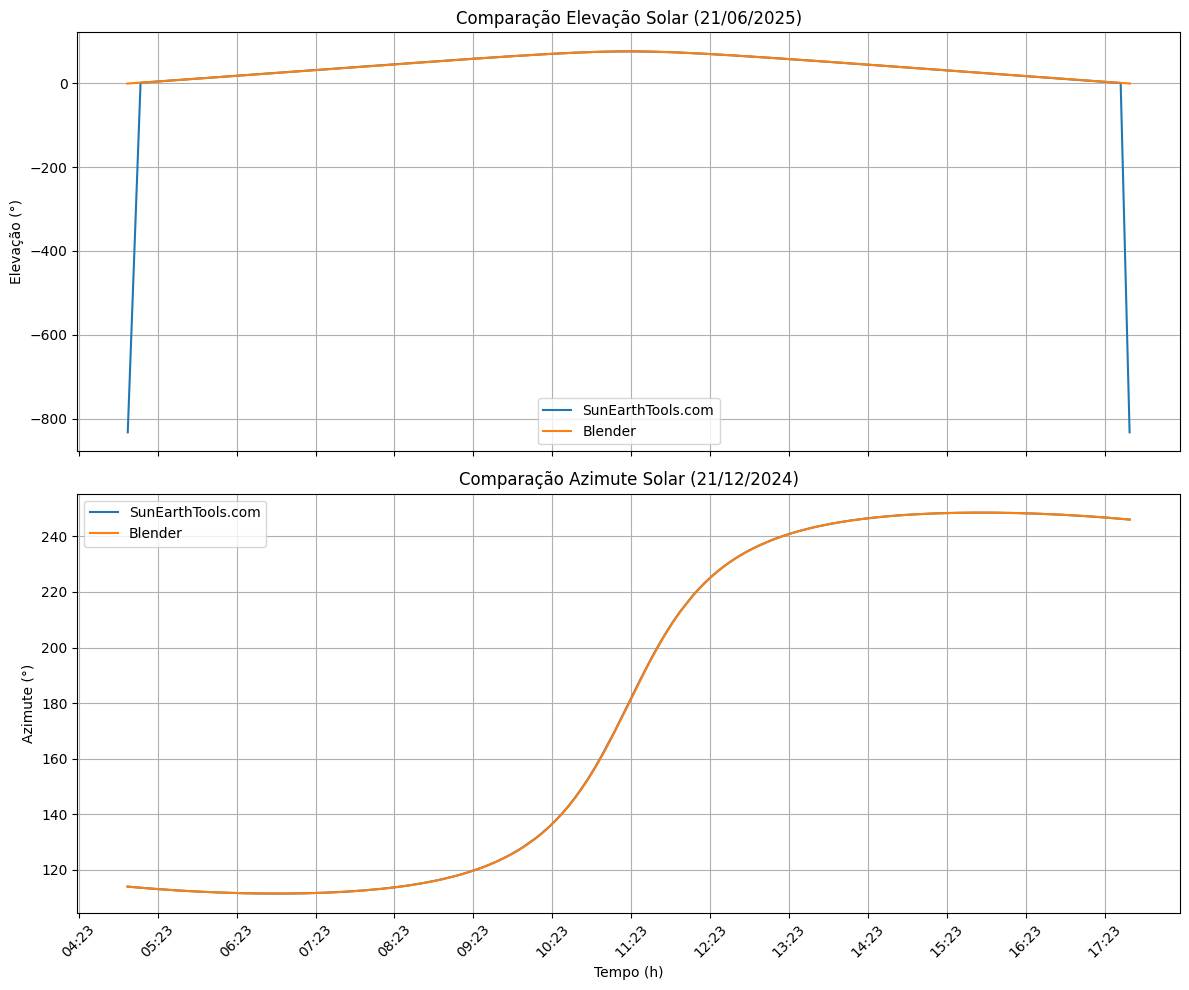

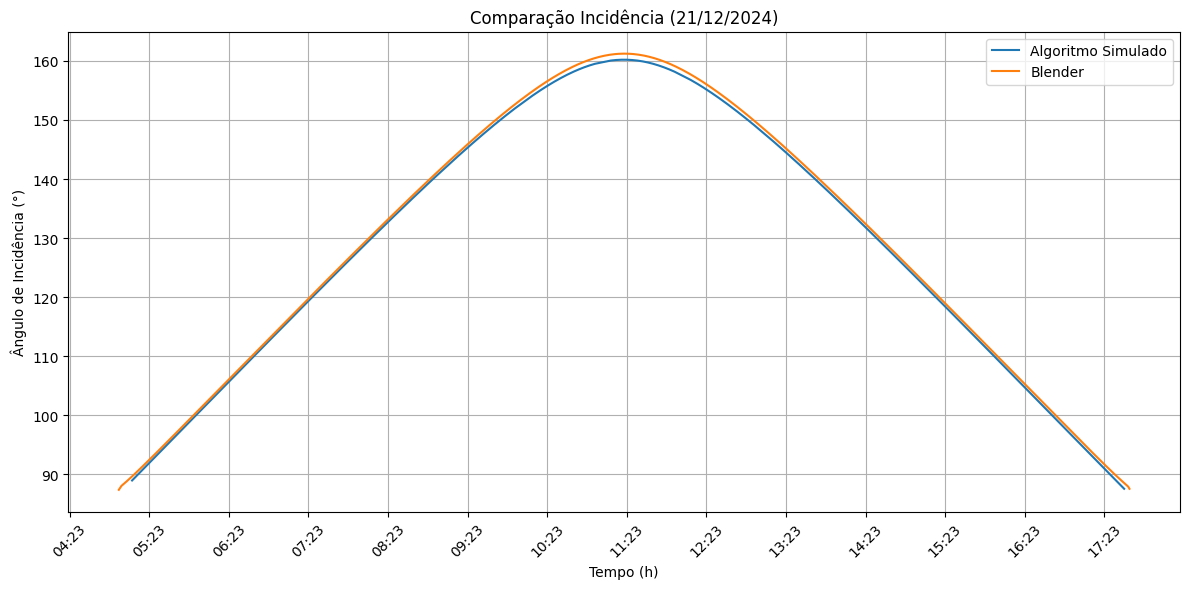

In [7]:
#Comparação 1 - Elevação e Azimute (SunEarthTools.com x Blender)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,10), sharex=True)

#Elevação em graus
ax1.plot(df1['Hora'], df1['Elevacao'], label='SunEarthTools.com')
ax1.plot(df2['Hora Solar'], df2['Elevação (°)'], label='Blender')

ax1.set_ylabel('Elevação (°)')
ax1.set_title('Comparação Elevação Solar (21/06/2025)')
ax1.legend()
ax1.grid(True)

#Azimute em graus
ax2.plot(df1['Hora'], df1['Azimute'], label='SunEarthTools.com')
ax2.plot(df2['Hora Solar'], df2['Azimute (°)'], label='Blender')

ax2.set_ylabel('Azimute (°)')
ax2.set_xlabel('Tempo (h)')
ax2.set_title('Comparação Azimute Solar (21/12/2024)')
ax2.legend()
ax2.grid(True)

#Format o eixo de tempo
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax2.xaxis.set_major_locator(mdates.MinuteLocator(interval=60))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#Comparação 2 - Ângulo de Incidência (Algoritmo x Blender)
fig, ax = plt.subplots(figsize=(12,6))

#Ângulo de Incidência em graus
ax.plot(df3['Tempo (HH:mm)'], df3['incidência fixo'], label='Algoritmo Simulado')
ax.plot(df2['Hora Solar'], df2['Ângulo de Incidência (°)'], label='Blender')

ax.set_ylabel('Ângulo de Incidência (°)')
ax.set_xlabel('Tempo (h)')
ax.set_title('Comparação Incidência (21/12/2024)')

ax.legend()
ax.grid(True)

#Format o eixo de tempo
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=60))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\abcal\AppData\Local\Temp\ipykernel_15048\2553931090.py:31: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



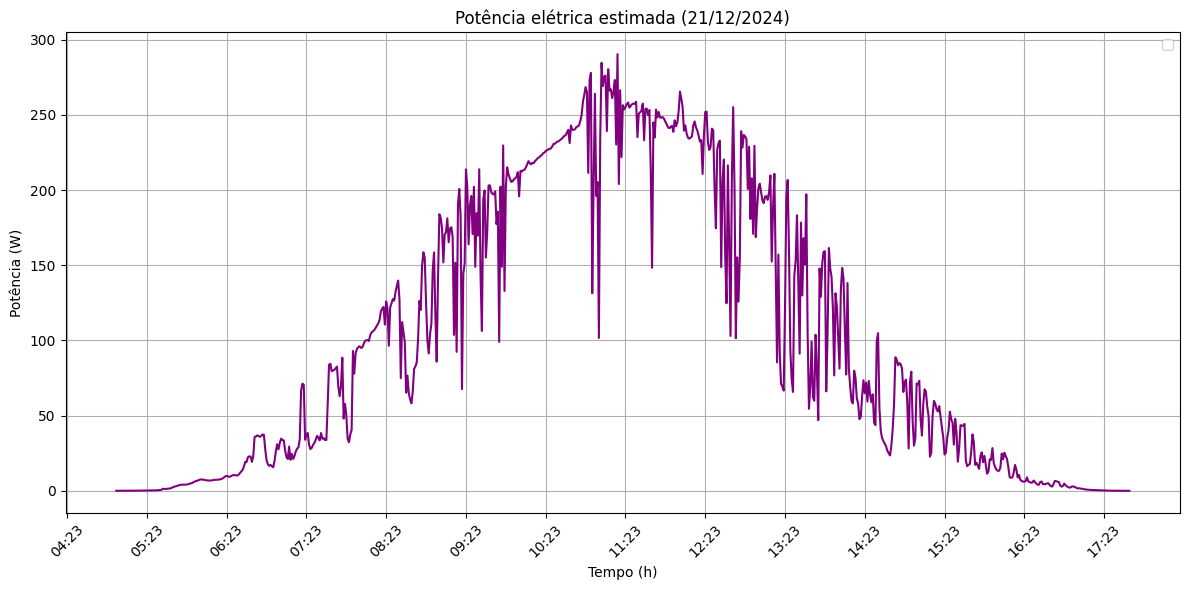

In [8]:
#Criação do df5 com todos os dados

df5 = pd.merge(df2,df4,left_on="Hora Solar",right_on="Hora",how="inner")

#Cálculo da Potência Elétrica

#Dados do painel
#Modelo - JKM270PP-60
#Dimensões - 1650 mm x 992 mm x 40 mm 
#Eficiência - 16,50%

a = 1.650*0.992
ef = 0.165

#Para que a potência fique positiva
w = np.radians(180 - df2["Ângulo de Incidência (°)"] )

#Potência = radiação*área*eficiência*cos(âng de incidência)
df5["Potencia (W)"] = (df5["Radiacao_Avg"] *a *ef *np.cos(w))

#Plot
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(df5["Hora Solar"], df5["Potencia (W)"], color="purple")

ax.set_title("Potência elétrica estimada (21/12/2024)")
ax.set_ylabel("Potência (W)")
ax.set_xlabel("Tempo (h)")

ax.grid(True)
ax.legend()

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=60))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [9]:
df5["Energia (Wh)"] = df5["Potencia (W)"] / 60

energia_total = df5["Energia (Wh)"].sum()

print("Energia total gerada no dia:",round(energia_total, 2), "Wh")

Energia total gerada no dia: 1290.3 Wh


In [10]:
#merge df5 e incidência
# Blender + SunEarthTools
df5 = pd.merge(df5, df1, left_on="Hora Solar", right_on="Hora", how="inner")

# adicionar algoritmo incidência
df5 = pd.merge(df5, df3, left_on="Hora Solar", right_on="Tempo (HH:mm)", how="inner")

In [11]:
#cálculo dos erros - erro percentual (medido-real/real)

df5['erro elevação'] = (abs(df5['Elevação (°)'] - df5['Elevacao_x'])/df5['Elevacao_x'])
df5['erro azimute'] = (abs(df5['Azimute (°)'] - df5['Azimute_x'])/df5['Azimute_x'])
df5['erro incidência'] = (abs(df5['Ângulo de Incidência (°)'] - df5['incidência fixo'])/ df5['incidência fixo'])


#Salvar em excel
df5.to_excel(r"C:\Users\abcal\Videos\df5.xlsx",index=False)

print(f"Erro médio elevação: {np.mean(df5['erro elevação'])} +- {np.std(df5['erro elevação'])}")
print(f"Erro médio azimute: {np.mean(df5['erro azimute'])} +- {np.std(df5['erro azimute'])}")
print(f"Erro médio incidência: {np.mean(df5['erro incidência'])} +- {np.std(df5['erro incidência'])}")

rmse_az = np.sqrt(np.mean(df5['erro azimute']**2))
rmse_el = np.sqrt(np.mean(df5['erro elevação']**2))
rmse_inc = np.sqrt(np.mean(df5['erro incidência']**2))

print(f"RMSE Elevação: {rmse_el}")
print(f"RMSE Azimute: {rmse_az}")
print(f"RMSE Incidência: {rmse_inc}")

Erro médio elevação: 0.012795742285656433 +- 0.061275722247563995
Erro médio azimute: 0.00025954075705932544 +- 0.00035393794128106104
Erro médio incidência: 0.004839091773093017 +- 0.0012447992971272792
RMSE Elevação: 0.06259748523384581
RMSE Azimute: 0.000438900297166912
RMSE Incidência: 0.004996632313723425


In [12]:
df5.columns

Index(['Frame', 'Hora Solar', 'Ângulo de Incidência (°)', 'Elevação (°)',
       'Azimute (°)', 'Data', 'Hora_x', 'Radiacao_Avg', 'Potencia (W)',
       'Energia (Wh)', 'Hora_y', 'Elevacao_x', 'Azimute_x',
       'tempo (incremental)', 'Tempo (HH:mm)', 'Tempo solar (HH:mm)',
       'horário', 'Zenital', 'Elevacao_y', 'Azimute_y', 'Incidencia',
       'Inclinação', 'orientação', 'incidência fixo', 'erro elevação',
       'erro azimute', 'erro incidência'],
      dtype='object')

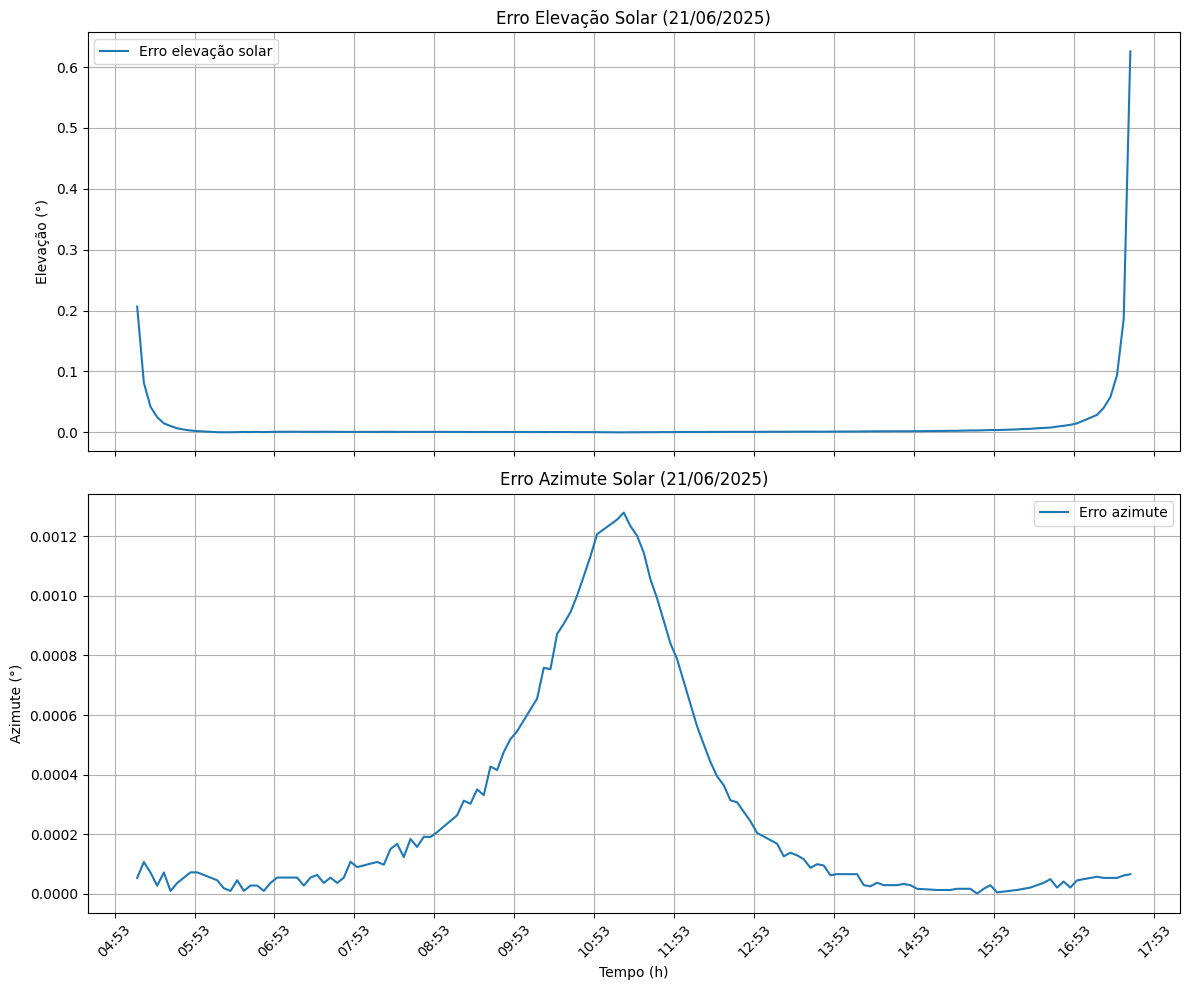

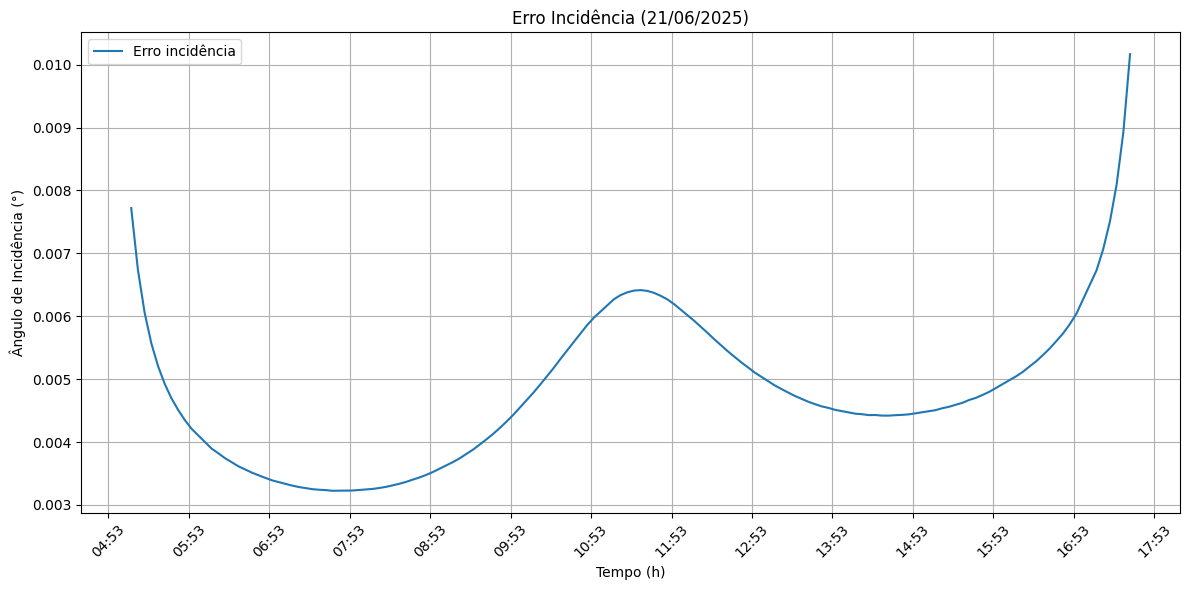

In [13]:
#Visualização dos erros
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,10), sharex=True)

#Elevação em graus
ax1.plot(df5['Hora Solar'], df5['erro elevação'], label='Erro elevação solar')

ax1.set_ylabel('Elevação (°)')
ax1.set_title('Erro Elevação Solar (21/06/2025)')
ax1.legend()
ax1.grid(True)

#Azimute em graus
ax2.plot(df5['Hora Solar'], df5['erro azimute'], label='Erro azimute')

ax2.set_ylabel('Azimute (°)')
ax2.set_xlabel('Tempo (h)')
ax2.set_title('Erro Azimute Solar (21/06/2025)')
ax2.legend()
ax2.grid(True)

#Format o eixo de tempo
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax2.xaxis.set_major_locator(mdates.MinuteLocator(interval=60))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#Comparação 2 - Ângulo de Incidência (Algoritmo x Blender)
fig, ax = plt.subplots(figsize=(12,6))

#Ângulo de Incidência em graus
ax.plot(df5['Hora Solar'], df5['erro incidência'], label='Erro incidência')


ax.set_ylabel('Ângulo de Incidência (°)')
ax.set_xlabel('Tempo (h)')
ax.set_title('Erro Incidência (21/06/2025)')

ax.legend()
ax.grid(True)

#Format o eixo de tempo
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=60))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()